# GLD (SPDR Gold Shares)

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import matplotlib

%matplotlib inline

C:\Users\niush\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
file_path = "GLD_categorized_data.csv"

categorized_df = pd.read_csv(file_path, delimiter=',')

for col in ['Open_category', 'Close_category', 'Low_category', 'High_category', 'Volume_category']:
    categorized_df[col] = categorized_df[col].astype('category')

categorized_df.head()

,Date,Open,High,Low,Close,Volume,Open_category,High_category,Low_category,Close_category,Volume_category
0,2005-09-21,0.000000,0.000593,0.000000,0.001786,0.067726,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0545, 0.0727]"
1,2005-09-29,0.002385,0.001439,0.002397,0.002127,0.034012,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0182, 0.0364]"
2,2005-10-11,0.006983,0.005587,0.006934,0.004594,0.028486,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0182, 0.0364]"
3,2005-10-12,0.008091,0.004909,0.002311,0.000000,0.079135,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0727, 0.0909]"
4,2005-10-13,0.002640,0.000000,0.000428,0.001446,0.019555,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0182, 0.0364]"


# Clustering

#### K-means

0. date formatting

In [3]:
# Check the Date column
print(categorized_df['Date'].head(10))

# Convert the Date column to datetime with a specified format
categorized_df['Date'] = pd.to_datetime(categorized_df['Date'], format='%Y-%m-%d', errors='coerce')

# Identify invalid dates
invalid_dates = categorized_df[categorized_df['Date'].isna()]
print("Invalid Dates:")
print(invalid_dates)

# Remove rows with invalid dates
categorized_df = categorized_df.dropna(subset=['Date'])

# Recheck the data information
print(categorized_df.info())
categorized_df.head()

0    2005-09-21
1    2005-09-29
2    2005-10-11
3    2005-10-12
4    2005-10-13
5    2005-10-25
6    2005-10-26
7    2005-10-27
8    2005-11-16
9    2005-11-17
Name: Date, dtype: object
Invalid Dates:
Empty DataFrame
Columns: [Date, Open, High, Low, Close, Volume, Open_category, High_category, Low_category, Close_category, Volume_category]
Index: []
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2690 entries, 0 to 2689
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             2690 non-null   datetime64[ns]
 1   Open             2690 non-null   float64       
 2   High             2690 non-null   float64       
 3   Low              2690 non-null   float64       
 4   Close            2690 non-null   float64       
 5   Volume           2690 non-null   float64       
 6   Open_category    2690 non-null   category      
 7   High_category    2690 non-null   category      
 8   Low_ca

,Date,Open,High,Low,Close,Volume,Open_category,High_category,Low_category,Close_category,Volume_category
0,2005-09-21,0.000000,0.000593,0.000000,0.001786,0.067726,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0545, 0.0727]"
1,2005-09-29,0.002385,0.001439,0.002397,0.002127,0.034012,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0182, 0.0364]"
2,2005-10-11,0.006983,0.005587,0.006934,0.004594,0.028486,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0182, 0.0364]"
3,2005-10-12,0.008091,0.004909,0.002311,0.000000,0.079135,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0727, 0.0909]"
4,2005-10-13,0.002640,0.000000,0.000428,0.001446,0.019555,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0182, 0.0364]"


1. add features

In [4]:
categorized_df['Year'] = categorized_df['Date'].dt.year
categorized_df['Month'] = categorized_df['Date'].dt.month
categorized_df['Day'] = categorized_df['Date'].dt.day
categorized_df['Day_of_Week'] = categorized_df['Date'].dt.day_name()  # یا .dt.weekday برای مقدار عددی
categorized_df.head(10)

,Date,Open,High,Low,Close,Volume,Open_category,High_category,Low_category,Close_category,Volume_category,Year,Month,Day,Day_of_Week
0,2005-09-21,0.000000,0.000593,0.000000,0.001786,0.067726,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0545, 0.0727]",2005,9,21,Wednesday
1,2005-09-29,0.002385,0.001439,0.002397,0.002127,0.034012,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0182, 0.0364]",2005,9,29,Thursday
2,2005-10-11,0.006983,0.005587,0.006934,0.004594,0.028486,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0182, 0.0364]",2005,10,11,Tuesday
3,2005-10-12,0.008091,0.004909,0.002311,0.000000,0.079135,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0727, 0.0909]",2005,10,12,Wednesday
4,2005-10-13,0.002640,0.000000,0.000428,0.001446,0.019555,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0182, 0.0364]",2005,10,13,Thursday
5,2005-10-25,0.002981,0.001100,0.002996,0.001786,0.049767,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0364, 0.0545]",2005,10,25,Tuesday
6,2005-10-26,0.004343,0.001270,0.002910,0.000681,0.001937,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.0182]",2005,10,26,Wednesday
7,2005-10-27,0.006983,0.003047,0.004708,0.002807,0.011854,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.0182]",2005,10,27,Thursday
8,2005-11-16,0.006047,0.006094,0.005735,0.007912,0.006838,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.0182]",2005,11,16,Wednesday
9,2005-11-17,0.014052,0.012866,0.013867,0.013866,0.090237,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0727, 0.0909]",2005,11,17,Thursday


3. Selecting the number of clusters</br>
To select the optimal number of clusters, use the Elbow Method:

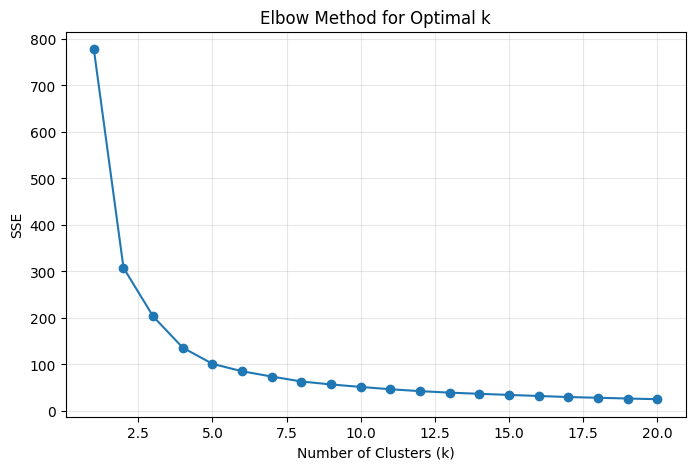

In [5]:
features = ['Open', 'High', 'Low', 'Close', 'Volume']

clistering_df = categorized_df.copy()

# Calculate SSE for different values of k
sse = []

# The range of the clusters
k_values = range(1, 21)
# n_init = 20

# hint: n_init and k_values must be equal => x, y
for k in k_values:
    # random_state = seed | n_init = amount of repetition of algorithm
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)  # Explicitly set n_init=10
    kmeans.fit(clistering_df[features])
    sse.append(kmeans.inertia_)

# Draw Elbow Plot
plt.figure(figsize=(8, 5))
plt.plot(k_values, sse, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("SSE")
plt.grid(alpha=0.3)
plt.show()

# The optimal number of clusters is at the point where the graph has a significant change (skeletal).


Clustering with K-Means

the choosed option here is k=5

In [6]:
# Running the K-Means algorithm with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42, n_init=20)
clustering_result = kmeans.fit_predict(clistering_df[features])

# Adding cluster labels to the DataFrame
clistering_df['Cluster'] = clustering_result
clistering_df.head()

,Date,Open,High,Low,Close,Volume,Open_category,High_category,Low_category,Close_category,Volume_category,Year,Month,Day,Day_of_Week,Cluster
0,2005-09-21,0.000000,0.000593,0.000000,0.001786,0.067726,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0545, 0.0727]",2005,9,21,Wednesday,2
1,2005-09-29,0.002385,0.001439,0.002397,0.002127,0.034012,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0182, 0.0364]",2005,9,29,Thursday,2
2,2005-10-11,0.006983,0.005587,0.006934,0.004594,0.028486,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0182, 0.0364]",2005,10,11,Tuesday,2
3,2005-10-12,0.008091,0.004909,0.002311,0.000000,0.079135,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0727, 0.0909]",2005,10,12,Wednesday,2
4,2005-10-13,0.002640,0.000000,0.000428,0.001446,0.019555,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0182, 0.0364]",2005,10,13,Thursday,2


Clustering Visualization

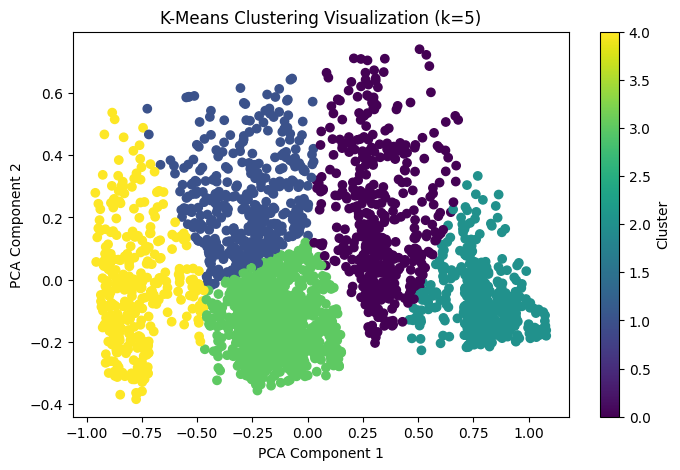

In [7]:
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(clistering_df[features])

plt.figure(figsize=(8, 5))
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=clistering_df['Cluster'], cmap='viridis', marker='o')
plt.title("K-Means Clustering Visualization (k=5)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label='Cluster')
plt.show()


Dimensionality reduction with PCA: </br>
o The data was reduced from a multidimensional space (5 features) to a two-dimensional space to visually display the clusters.


Graph analysis:</br>
1. Data dispersion:</br>
    o The data is scattered in a two-dimensional space (reduced with PCA).</br>
    o Each point represents a sample of your data (stock data).</br>


2. Cluster coloring:</br>
    o Points with different colors belong to different clusters (based on the cluster label ClusterClusterCluster).</br>


3. Cluster structure:</br>
    o The clusters are generally separate from each other, although some clusters (e.g. green and light blue) may overlap slightly.</br>
    o This indicates that the algorithm was able to identify patterns in the data.


Interpretation of Results:</br>
• The identified clusters can represent different groups in the stock data:</br>
    o Example: stocks with similar price behavior or volume.</br>
    o Clusters can be used to analyze market behavior, identify trading patterns, or segment data based on similar characteristics.

Examining the contribution of Volume to PCA components

In [8]:
pca_components = pd.DataFrame(pca.components_, columns=features)
print(pca_components)

       Open      High       Low     Close    Volume
0 -0.495813 -0.493821 -0.497387 -0.495500 -0.131898
1 -0.065245 -0.058473 -0.074040 -0.065967  0.991207


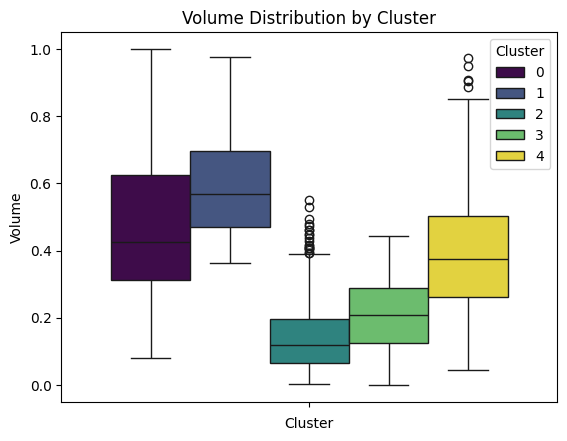

In [9]:
sns.boxplot(hue='Cluster', y='Volume', data=clistering_df, palette='viridis')
plt.title("Volume Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Volume")
plt.show()


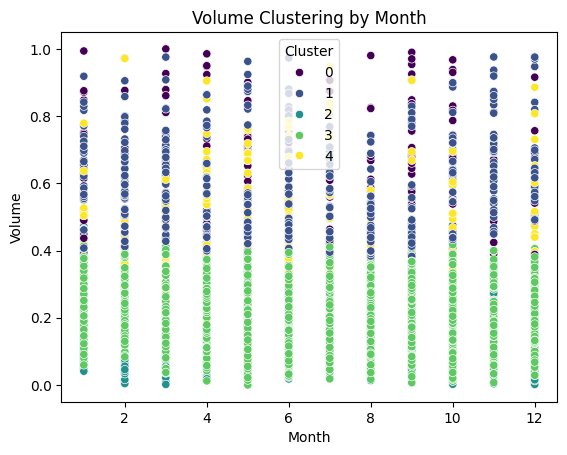

In [10]:
# Based on Volume

sns.scatterplot(
    x='Month', y='Volume', hue='Cluster', data=clistering_df, palette='viridis'
)
plt.title("Volume Clustering by Month")
plt.xlabel("Month")
plt.ylabel("Volume")
plt.legend(title="Cluster")
plt.show()

Identifying Clustering Patterns:


Cluster 4 (yellow):</br>
This cluster appears to contain data with high trading volume (Volume close to 1).</br>
This data may represent days or stocks with high trading activity.

Cluster 0 (purple):</br>
This cluster contains data with low trading volume (Volume close to 0).</br>
This cluster likely represents days or stocks with low trading activity.

Cluster 1, Cluster 2, and Cluster 3 (middle colors):</br>
These clusters cover data with medium trading volume.</br>
These clusters may be formed based on fluctuations or changes in trading volume in different months of the year.

Different colors in clusters (top and bottom):</br>
Each color represents a cluster.

Vertical position (Volume):
The position of the points on the y-axis is determined by the amount of trading volume (Volume).</br>
Higher points have more trading volume.</br>
Lower points have less trading volume.

Why are the points of a cluster visible at the top and bottom?</br>
Intermediate clusters (such as Cluster 1, Cluster 2, or Cluster 3) may contain points from the high </br>
    (volume close to the higher average) and low (volume close to the lower average) regions on the Volume scale.</br>
This occurs due to the combination of other clustering features (such as Open, High, and Close).

If a cluster contains data with a different combination of price features (Open, Close, High, Low)</br>
    but the Volume value fluctuates, the points of that cluster may be visible at the top and bottom of the chart.

Each circle on the chart represents one trading day.</br>
The number of circles in each column (month) should equal the number of trading days in that month.</br>
For example: if a month has 22 trading days, there are 22 circles for that month on the chart.

In [11]:
days_per_year_month = clistering_df.groupby(['Year', 'Month']).size()
print(days_per_year_month)

Year  Month
2005  9         2
      10        6
      11        5
      12       18
2006  1        20
               ..
2017  7        20
      8        23
      9        20
      10       22
      11        8
Length: 144, dtype: int64


In [12]:
print(clistering_df['Year'].unique())

[2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017]


In [13]:
days_per_month = clistering_df.groupby('Month').size()
print(days_per_month)

Month
1     226
2     193
3     242
4     238
5     236
6     245
7     242
8     240
9     200
10    231
11    186
12    211
dtype: int64


In [14]:
cluster_by_month = clistering_df.groupby(['Month', 'Cluster']).size().unstack()
print(cluster_by_month)

Cluster   0   1   2    3   4
Month                       
1        41  37  40   71  37
2        29  45  37   62  20
3        33  43  43   77  46
4        42  26  39   83  48
5        49  28  35   78  46
6        42  37  40   84  42
7        41  30  39   93  39
8        41  27  43  104  25
9        39  29  36   93   3
10       39  33  44  100  15
11       27  37  39   81   2
12       28  28  51   82  22


Observations:


Cluster 0 (low trading volume):</br>
Has more data in months 5 and 8 than in other months (47 and 41 samples).</br>
It is generally present in all months and seems to be a stable cluster.


Cluster 1 (very low trading volume):</br>
This cluster is very prominent in month 7 (62 samples).</br>
It also has a relatively large number of data in months 4 and 8 (52 and 52 samples).


Cluster 2 (medium trading volume):</br>
This cluster is most numerous in months 6, 7 and 9 (47, 42 and 53 samples).</br>
This cluster represents medium-volume data that is present variably across months.


Cluster 3 (above-average trading volume):</br>
Has more data in months 3 and 4 (28 and 27 samples).</br>
Fewer numbers are observed in months 11 and 12 (10 and 18 samples).


Cluster 4 (high trading volume):</br>
It has the largest number of data in month 4 (38 samples).</br>
It has the lowest number in month 8 (11 samples).


Conclusions from the cluster distribution:</br>
Clusters 0 and Cluster 1 are widely and consistently observed in all months and represent low volume data.</br>
Clusters with medium volume (Cluster 2 and Cluster 3) are more prominent in certain months such as 6 and 7.</br>
Cluster 4, which represents high trading volume, is most prominent in month 4 and less present in other months.

In [15]:
cluster_means = clistering_df.groupby('Cluster')['Volume'].mean()
print(cluster_means)


Cluster
0    0.470896
1    0.597049
2    0.143117
3    0.209177
4    0.395894
Name: Volume, dtype: float64


Observations:

Cluster 0:</br>
The average trading volume in this cluster is around 0.39.</br>
This cluster represents data with trading volume close to the low average level.

Cluster 1:</br>
It has the lowest average trading volume (0.15).</br>
This cluster corresponds to data with very low trading activity.

Cluster 2:</br>
Its average trading volume is 0.20 and represents data with slightly higher volume than Cluster 1.

Cluster 3:</br>
Its average trading volume is 0.47 and represents data with higher volume than the average.

Cluster 4:</br>
It has the highest average trading volume (0.74).</br>
This cluster corresponds to days or stocks with very high trading activity.


Conclusion of average trading volume:</br>
The clusters are well separated from each other in terms of trading volume:</br>
Cluster 1 and Cluster 2 have low and relatively low trading volumes.</br>
Clusters 3 and 4 represent above-average and very high trading volumes.

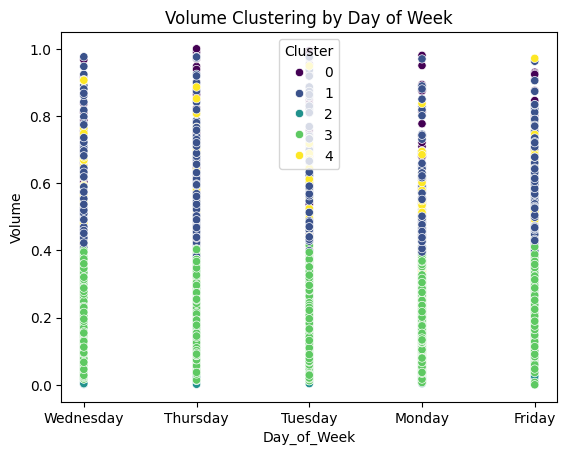

In [16]:
sns.scatterplot(
    x='Day_of_Week', y='Volume', hue='Cluster', data=clistering_df, palette='viridis'
)
plt.title("Volume Clustering by Day of Week")
plt.xlabel("Day_of_Week")
plt.ylabel("Volume")
plt.legend(title="Cluster")
plt.show()

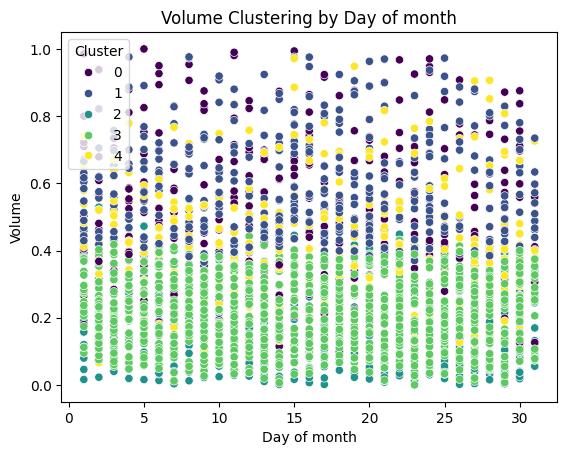

In [17]:
sns.scatterplot(
    x='Day', y='Volume', hue='Cluster', data=clistering_df, palette='viridis'
)
plt.title("Volume Clustering by Day of month")
plt.xlabel("Day of month")
plt.ylabel("Volume")
plt.legend(title="Cluster")
plt.show()

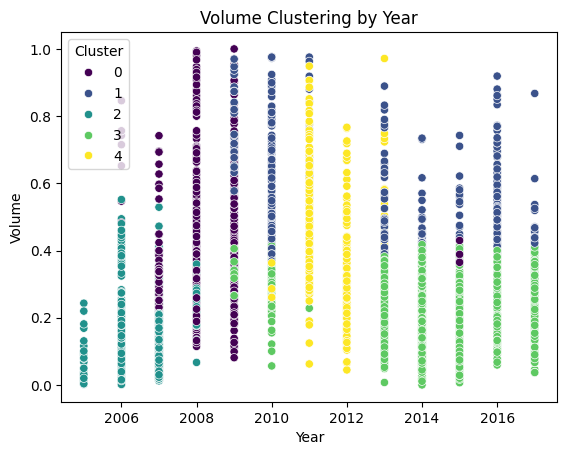

In [18]:
sns.scatterplot(
    x='Year', y='Volume', hue='Cluster', data=clistering_df, palette='viridis'
)
plt.title("Volume Clustering by Year")
plt.xlabel("Year")
plt.ylabel("Volume")
plt.legend(title="Cluster")
plt.show()

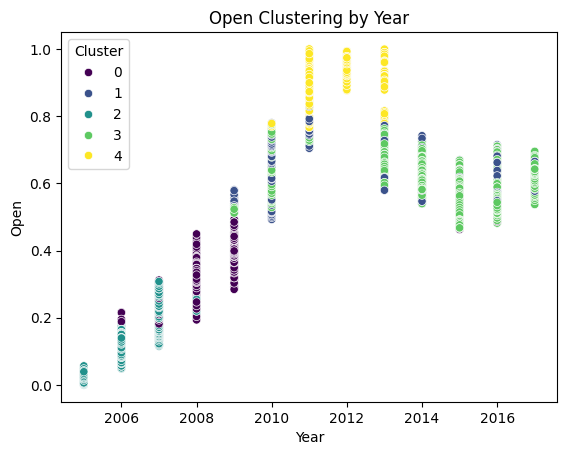

In [19]:
sns.scatterplot(
    x='Year', y='Open', hue='Cluster', data=clistering_df, palette='viridis'
)
plt.title("Open Clustering by Year")
plt.xlabel("Year")
plt.ylabel("Open")
plt.legend(title="Cluster")
plt.show()

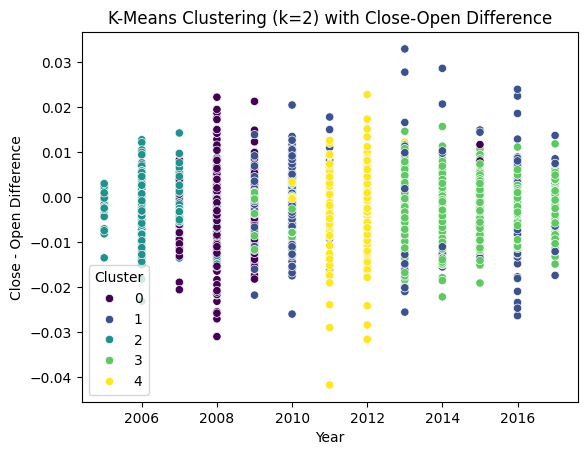

In [20]:
# Create a new column for the difference between Close and Open
clistering_df['Close_Open_Diff'] = clistering_df['Close'] - clistering_df['Open']

# Scatter plot with the difference as y-axis
sns.scatterplot(
    x='Year', y='Close_Open_Diff', hue='Cluster', data=clistering_df, palette='viridis'
)
plt.title("K-Means Clustering (k=2) with Close-Open Difference")
plt.xlabel("Year")
plt.ylabel("Close - Open Difference")
plt.legend(title="Cluster")
plt.show()
